In [2]:
#25 de junio
#Modificacion del ejemplo de Lorenz
#Filtraré los datos de la matriz de Hankel H (de manera equivalente, X_delay) usando el encoder SVD

In [3]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.integrate import solve_ivp
import pysindy as ps

In [4]:
#Modelo real del sistema de Lorenz
def lorenz(t,state,sigma=10, rho=28, beta=8/3):
    x,y,z = state
    return [sigma * (y - x), x * (rho - z) - y, x * y - beta * z]

In [5]:
#Genero datos reales de x (que equivale a x1)
dt = 0.01
t_span = (0, 50) #Empiezo en el segundo 0 y acabo en el 50
t_eval = np.arange(t_span[0], t_span[1], dt) #Vector que divide 0 a 50 en intervalos de 0.01 de longitud
x0 = [-8, 7, 27] #Inicializo el problema

sol = solve_ivp(lorenz, t_span, x0, t_eval=t_eval)
X_real = sol.y.T  # Dimensiones: (muestras, 3). Me devolvio el supuesto valor de x,y,z en 0,0.01,0.02,...,50
print("X_real=\n",X_real)
print(f"Forma de la matriz de soluciones reales X_real: {X_real.shape}")

# Fingimos que solo medimos la primera variable x (==x1) y le añadimos ruido
y_medido = X_real[:, 0] + np.random.normal(0, 0.05, size=len(t_eval))

X_real=
 [[ -8.           7.          27.        ]
 [ -6.58106657   6.81495487  25.79328661]
 [ -5.31708157   6.58547425  24.72174693]
 ...
 [ -5.57014667  -8.9938366   15.73928652]
 [ -5.92504552  -9.60194295  15.85234761]
 [ -6.30556508 -10.24001749  16.03388567]]
Forma de la matriz de soluciones reales X_real: (5000, 3)


In [6]:
#Creamos el espacio de retardos (embedding)
#El teorema de Taken dice que n>2m y en este caso m=3, por lo que n debería ser 7
#Sin embargo, como conozco el modelo de Lorenz (se supone que no), n=3 bastará porque corresponde a las 3 variables del sistema
#Sin embargo, voy a usar n mayor para demostrar la reduccion de dimensionalidad gracias al encoder
n_delays = 15   # Dimensión de incrustación (creamos z1, z2, ...,z15)
tau = 5       # retraso temporal (delay)

#X_delay es H matriz de Hankel del articulo pero traspuesta
r=len(y_medido) - (n_delays - 1) * tau
X_delay = np.zeros((r, n_delays)) 
for i in range(n_delays):
    X_delay[:, i] = y_medido[i * tau : r + i * tau]  #En la columna i, meto los datos de y desde i*tau hasta r+i*tau

print(f"Forma X_delay:{X_delay.shape}")

# El tiempo correspondiente al recorte del embedding
t_delay = t_eval[0 : X_delay.shape[0]] 

Forma X_delay:(4930, 15)


In [7]:
#ENCODER LINEAL (filtro ruido y reduzo dimension gracias a SVD)
U,Sigma,Vt = np.linalg.svd(X_delay,full_matrices=False)
#full_matrices=False reduce las dimensiones de U y Vt al mínimo para reconstruir X_delay (se queda con el rango) 
print(f"Forma de Sigma:{Sigma.shape}")
print(f"Forma de U: {U.shape}")
print(f"Forma de Vt: {Vt.shape}")
#-----------------------------------------------------------------------------------------------------
#En el articulo, se hace la descomposicion SVD de H (=X_delay traspuesta) y luego z=h(traspuesta)*Up donde h=[y(t), y(t + τ ), y(t + 2τ ), ... , y(t + (n − 1)τ )]
#Por tanto, U (en el articulo) es V (en Python) y V(en el articulo) es U (en Python)
#------------------------------------------------------------------------------------------------------
#Renombro las matrices como en el articulo
W=U
U=Vt.T
V=W

#De todas formas, supongo que U podría haberse quedado con más columnas después de SVD.
#Por eso, reduzo aún más la dimension de U. Me quedo con 3 columnas ya que, como el sistema real de Lorenz funciona con 3 variables,
#tiene sentido pensar que solo hacen falta 3 columnas en U para explicar el sistema.
p=3
Up=U[:,0:p]

#Creación del espacio latente Z
Z=X_delay @ Up
print(f"Dimensión del espacio de retardo H: {X_delay.shape}")
print(f"Dimensión del espacio latente Z: {Z.shape}")

Forma de Sigma:(15,)
Forma de U: (4930, 15)
Forma de Vt: (15, 15)
Dimensión del espacio de retardo H: (4930, 15)
Dimensión del espacio latente Z: (4930, 3)


In [8]:
#Aplicamos SINDy
model = ps.SINDy(feature_library=ps.PolynomialLibrary(degree=2), 
                 optimizer=ps.STLSQ(threshold=0.1))
model.fit(Z, t=dt)

# Ecuaciones analíticas descubiertas
print("\n--- ECUACIONES DINÁMICAS DESCUBIERTAS EN EL ESPACIO DE RETARDO (H) ---")
model.print()



--- ECUACIONES DINÁMICAS DESCUBIERTAS EN EL ESPACIO DE RETARDO (H) ---
(x0)' = -0.183 1 +  3.289 x1
(x1)' = -2.363 1 + -1.284 x0 + -7.279 x2
(x2)' =  0.610 1 +  3.254 x1


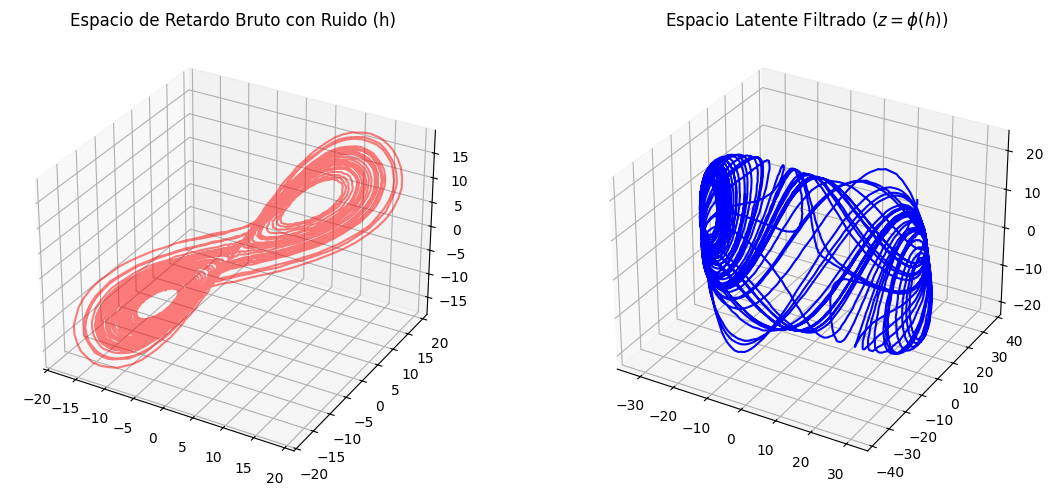

In [9]:
#Gráficos
fig = plt.figure(figsize=(12, 5))

# Espacio de Retardo h (mostramos solo 3 dimensiones de las 15)
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(X_delay[:, 0], X_delay[:, 1], X_delay[:, 2], color='r', alpha=0.5)
ax1.set_title("Espacio de Retardo Bruto con Ruido (h)")

# Espacio Latente Z 
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(Z[:, 0], Z[:, 1], Z[:, 2], color='b')
ax2.set_title("Espacio Latente Filtrado ($z = \\phi(h)$)")

plt.tight_layout()
plt.show()